# Optimization and Regularization 실습

## 학습 목표
- optimizer와 learning rate의 역할 이해
- SGD와 Adam 비교
- weight decay와 dropout 효과 확인
- FashionMNIST의 validation accuracy 변화 관찰
- regularization이 왜 필요한지 정리


## 1. 데이터 준비


device: cpu
train: 1600 val: 400
images shape: (64, 1, 28, 28)
labels shape: (64,)


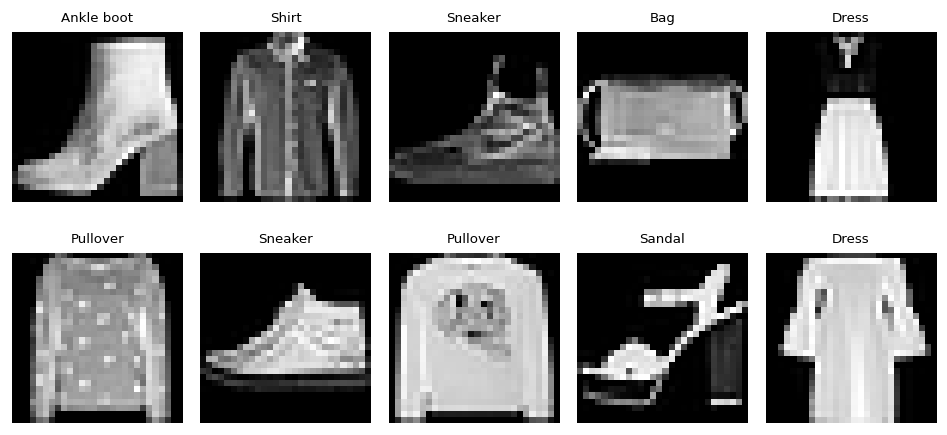

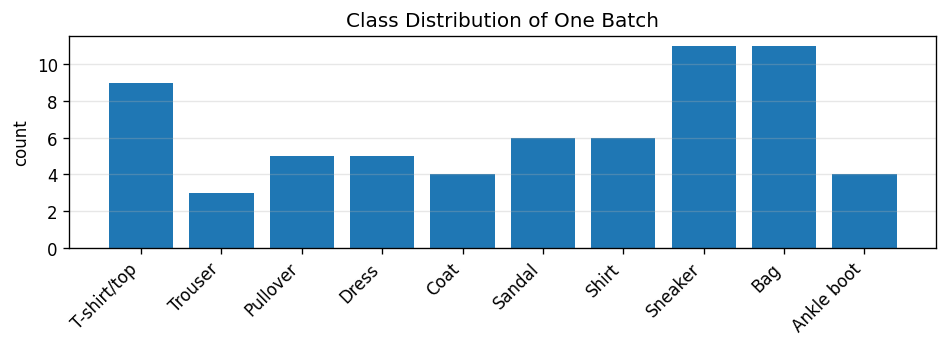

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader, Subset, TensorDataset, random_split

# 재현성 고정
np.random.seed(42)
torch.manual_seed(42)
plt.rcParams["figure.dpi"] = 120

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

def read_idx_images(path):
    # 이미지 읽기
    with open(path, "rb") as f:
        _ = int.from_bytes(f.read(4), "big")
        count = int.from_bytes(f.read(4), "big")
        rows = int.from_bytes(f.read(4), "big")
        cols = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8).reshape(count, rows, cols)
    return torch.tensor(data, dtype=torch.float32).unsqueeze(1) / 255.0


def read_idx_labels(path):
    # 라벨 읽기
    with open(path, "rb") as f:
        _ = int.from_bytes(f.read(4), "big")
        count = int.from_bytes(f.read(4), "big")
        data = np.frombuffer(f.read(), dtype=np.uint8)
    return torch.tensor(data[:count], dtype=torch.long)


data_root = Path("코드/data/FashionMNIST/raw")
train_images = read_idx_images(data_root / "train-images-idx3-ubyte")
train_labels = read_idx_labels(data_root / "train-labels-idx1-ubyte")
full_train = TensorDataset(train_images, train_labels)
subset = Subset(full_train, range(2000))
train_dataset, val_dataset = random_split(
    subset,
    [1600, 400],
    generator=torch.Generator().manual_seed(42),
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("device:", device)
print("train:", len(train_dataset), "val:", len(val_dataset))

images, labels = next(iter(train_loader))
print("images shape:", tuple(images.shape))
print("labels shape:", tuple(labels.shape))

# 배치 예시
fig, axes = plt.subplots(2, 5, figsize=(8, 4))
for ax, image, label in zip(axes.ravel(), images[:10], labels[:10]):
    ax.imshow(image[0], cmap="gray")
    ax.set_title(class_names[label.item()], fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

# 라벨 분포
label_counts = torch.bincount(labels, minlength=10)
plt.figure(figsize=(8, 3))
plt.bar(range(10), label_counts.numpy())
plt.xticks(range(10), class_names, rotation=45, ha="right")
plt.ylabel("count")
plt.title("Class Distribution of One Batch")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## 2. BasicMLP 구현

`Flatten -> Linear -> ReLU -> Dropout -> Linear`


In [2]:
class BasicMLP(nn.Module):
    # 기본 MLP
    def __init__(self, hidden_dim=128, dropout_p=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(hidden_dim, 10),
        )

    def forward(self, x):
        return self.net(x)


## 3. evaluate / train_model 구현


In [3]:
criterion = nn.CrossEntropyLoss()


def evaluate(model, loader, criterion):
    # 평가 함수
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_count = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

    return total_loss / total_count, total_correct / total_count


def train_model(model, train_loader, val_loader, optimizer, criterion, epochs=5):
    # 학습 함수
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()

            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_count += x.size(0)

        train_loss = total_loss / total_count
        train_acc = total_correct / total_count
        val_loss, val_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"epoch {epoch + 1}: "
            f"train_acc={train_acc:.4f}, val_acc={val_acc:.4f}"
        )

    return history


def print_final_acc(histories):
    # 최종 정확도
    for name, history in histories.items():
        print(f"{name:>12} | val_acc={history['val_acc'][-1]:.4f}")


def plot_compare(histories, left_key, right_key, left_title, right_title):
    # 비교 그래프
    epochs = range(1, len(next(iter(histories.values()))[left_key]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))

    for name, history in histories.items():
        axes[0].plot(epochs, history[left_key], marker="o", label=name)
        axes[1].plot(epochs, history[right_key], marker="o", label=name)

    axes[0].set_title(left_title)
    axes[1].set_title(right_title)
    for ax in axes:
        ax.set_xlabel("Epoch")
        ax.grid(alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.show()


## 4. SGD vs Adam 비교



[SGD]
epoch 1: train_acc=0.4662, val_acc=0.6200
epoch 2: train_acc=0.6369, val_acc=0.6475
epoch 3: train_acc=0.6819, val_acc=0.6675
epoch 4: train_acc=0.7056, val_acc=0.6950
epoch 5: train_acc=0.7431, val_acc=0.7575

[Adam]
epoch 1: train_acc=0.5581, val_acc=0.6700
epoch 2: train_acc=0.6894, val_acc=0.6900
epoch 3: train_acc=0.7506, val_acc=0.7400
epoch 4: train_acc=0.7875, val_acc=0.7850
epoch 5: train_acc=0.8063, val_acc=0.7700
         SGD | val_acc=0.7575
        Adam | val_acc=0.7700


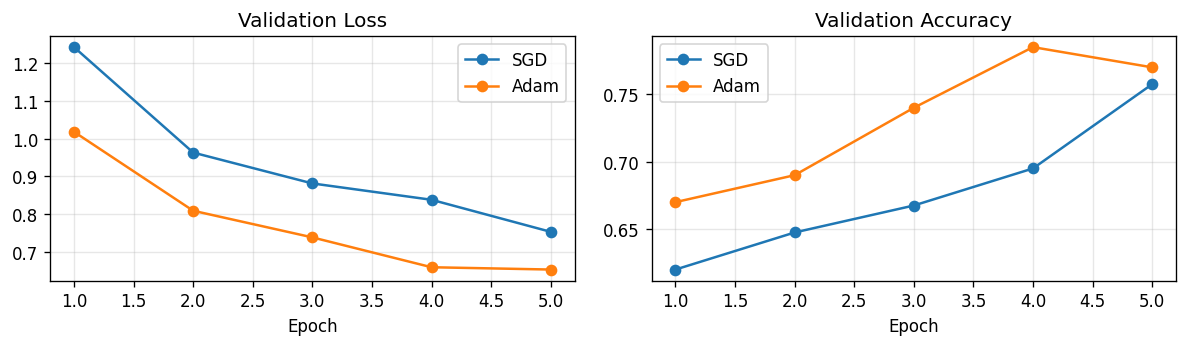

In [4]:
sgd_vs_adam = {}
for name, optimizer_cls, lr in [
    ("SGD", torch.optim.SGD, 0.1),
    ("Adam", torch.optim.Adam, 1e-3),
]:
    print(f"\n[{name}]")
    model = BasicMLP(hidden_dim=128, dropout_p=0.0).to(device)
    optimizer = optimizer_cls(model.parameters(), lr=lr)
    sgd_vs_adam[name] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(sgd_vs_adam)
plot_compare(
    sgd_vs_adam,
    "val_loss",
    "val_acc",
    "Validation Loss",
    "Validation Accuracy",
)


## 5. SGD learning rate 비교



[SGD lr=0.001]
epoch 1: train_acc=0.1044, val_acc=0.1300
epoch 2: train_acc=0.1081, val_acc=0.1350
epoch 3: train_acc=0.1119, val_acc=0.1350
epoch 4: train_acc=0.1144, val_acc=0.1425
epoch 5: train_acc=0.1206, val_acc=0.1500

[SGD lr=0.01]
epoch 1: train_acc=0.1787, val_acc=0.3800
epoch 2: train_acc=0.4863, val_acc=0.5775
epoch 3: train_acc=0.5506, val_acc=0.5800
epoch 4: train_acc=0.5806, val_acc=0.5850
epoch 5: train_acc=0.5850, val_acc=0.5975

[SGD lr=0.1]
epoch 1: train_acc=0.4637, val_acc=0.6000
epoch 2: train_acc=0.6100, val_acc=0.6050
epoch 3: train_acc=0.6806, val_acc=0.6875
epoch 4: train_acc=0.6825, val_acc=0.7050
epoch 5: train_acc=0.7412, val_acc=0.7375
    lr=0.001 | val_acc=0.1500
     lr=0.01 | val_acc=0.5975
      lr=0.1 | val_acc=0.7375


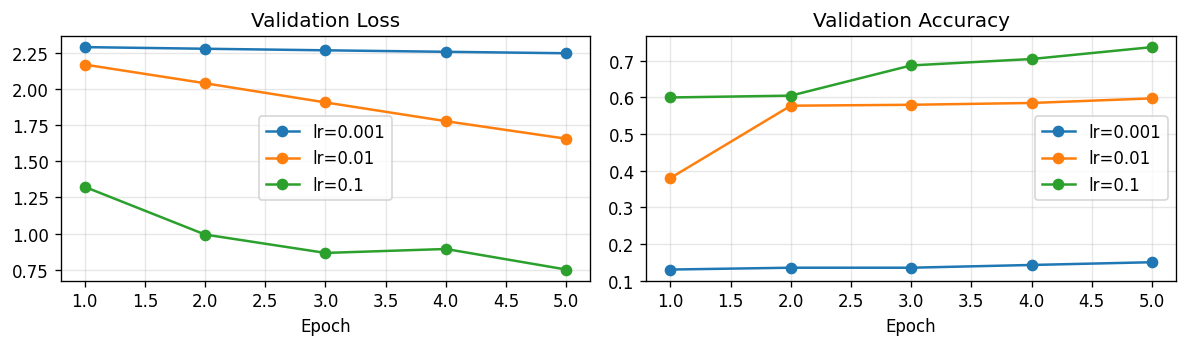

In [5]:
lr_histories = {}
for lr in [0.001, 0.01, 0.1]:
    print(f"\n[SGD lr={lr}]")
    model = BasicMLP(hidden_dim=128, dropout_p=0.0).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    lr_histories[f"lr={lr}"] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(lr_histories)
plot_compare(
    lr_histories,
    "val_loss",
    "val_acc",
    "Validation Loss",
    "Validation Accuracy",
)


## 6. baseline vs weight decay vs dropout 비교



[baseline]
epoch 1: train_acc=0.5325, val_acc=0.6500
epoch 2: train_acc=0.7013, val_acc=0.7150
epoch 3: train_acc=0.7644, val_acc=0.7775
epoch 4: train_acc=0.7925, val_acc=0.8000
epoch 5: train_acc=0.8156, val_acc=0.8025

[weight decay]
epoch 1: train_acc=0.5162, val_acc=0.6675
epoch 2: train_acc=0.7019, val_acc=0.7150
epoch 3: train_acc=0.7488, val_acc=0.7725
epoch 4: train_acc=0.7769, val_acc=0.7425
epoch 5: train_acc=0.7975, val_acc=0.7775

[dropout]
epoch 1: train_acc=0.4744, val_acc=0.6550
epoch 2: train_acc=0.6694, val_acc=0.6925
epoch 3: train_acc=0.7063, val_acc=0.7450
epoch 4: train_acc=0.7462, val_acc=0.7625
epoch 5: train_acc=0.7600, val_acc=0.7850
    baseline | val_acc=0.8025
weight decay | val_acc=0.7775
     dropout | val_acc=0.7850


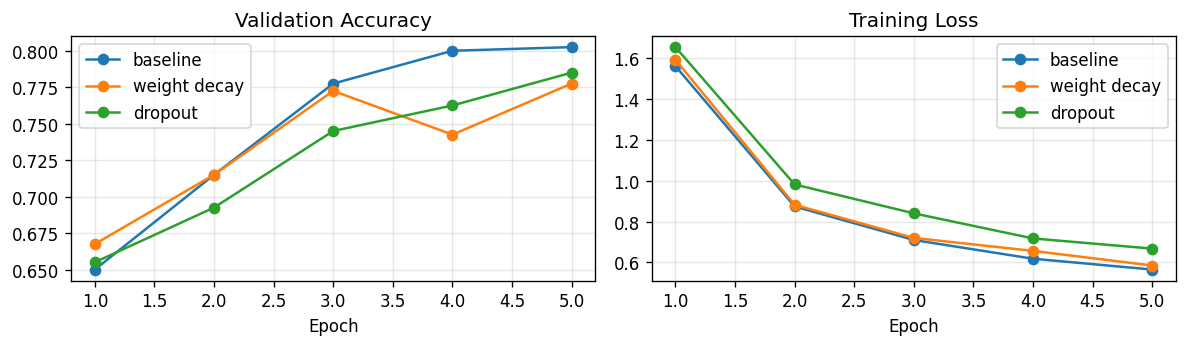

In [6]:
reg_histories = {}
reg_configs = {
    "baseline": {"dropout_p": 0.0, "weight_decay": 0.0},
    "weight decay": {"dropout_p": 0.0, "weight_decay": 1e-4},
    "dropout": {"dropout_p": 0.3, "weight_decay": 0.0},
}

for name, cfg in reg_configs.items():
    print(f"\n[{name}]")
    model = BasicMLP(hidden_dim=128, dropout_p=cfg["dropout_p"]).to(device)
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=1e-3,
        weight_decay=cfg["weight_decay"],
    )
    reg_histories[name] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(reg_histories)
plot_compare(
    reg_histories,
    "val_acc",
    "train_loss",
    "Validation Accuracy",
    "Training Loss",
)


## 7. 짧은 핵심 정리
- optimizer: gradient를 실제 update로 바꾼다.
- learning rate: update 크기를 정한다.
- Adam vs SGD: 같은 모델도 학습 속도와 안정성이 다를 수 있다.
- weight decay: 큰 가중치를 억제해 과적합을 줄인다.
- dropout: 일부 뉴런을 잠시 꺼서 특정 뉴런 의존을 줄인다.
- validation accuracy를 함께 보며 비교한다.

## 연습 문제 확장 포인트
- learning rate: `0.0001`, `0.5`
- hidden_dim: `64`, `256`
- weight_decay: `1e-5`, `1e-3`
- dropout: `0.1`, `0.5`


## 8. 연습 문제 구현


### Exercise 1
SGD와 Adam 중 validation accuracy가 더 빨리 올라가는 쪽 확인


In [7]:
# 초반 비교
early_mean = {
    name: round(float(np.mean(history["val_acc"][:3])), 4)
    for name, history in sgd_vs_adam.items()
}

for epoch, (sgd_acc, adam_acc) in enumerate(
    zip(sgd_vs_adam["SGD"]["val_acc"], sgd_vs_adam["Adam"]["val_acc"]),
    start=1,
):
    print(f"epoch {epoch}: SGD={sgd_acc:.4f}, Adam={adam_acc:.4f}")

faster = max(early_mean, key=early_mean.get)
print("\n초반 3epoch 평균 val_acc:", early_mean)
print("더 빨리 올라간 쪽:", faster)


epoch 1: SGD=0.6200, Adam=0.6700
epoch 2: SGD=0.6475, Adam=0.6900
epoch 3: SGD=0.6675, Adam=0.7400
epoch 4: SGD=0.6950, Adam=0.7850
epoch 5: SGD=0.7575, Adam=0.7700

초반 3epoch 평균 val_acc: {'SGD': 0.645, 'Adam': 0.7}
더 빨리 올라간 쪽: Adam


### Exercise 2
SGD learning rate를 `0.0001`, `0.5`로 바꿈 비교



[SGD lr=0.0001]
epoch 1: train_acc=0.0900, val_acc=0.0975
epoch 2: train_acc=0.0912, val_acc=0.1000
epoch 3: train_acc=0.0919, val_acc=0.1025
epoch 4: train_acc=0.0912, val_acc=0.1025
epoch 5: train_acc=0.0938, val_acc=0.1025

[SGD lr=0.5]
epoch 1: train_acc=0.3281, val_acc=0.5050
epoch 2: train_acc=0.4313, val_acc=0.4150
epoch 3: train_acc=0.5106, val_acc=0.6025
epoch 4: train_acc=0.5656, val_acc=0.6475
epoch 5: train_acc=0.6056, val_acc=0.6275
   lr=0.0001 | val_acc=0.1025
      lr=0.5 | val_acc=0.6275


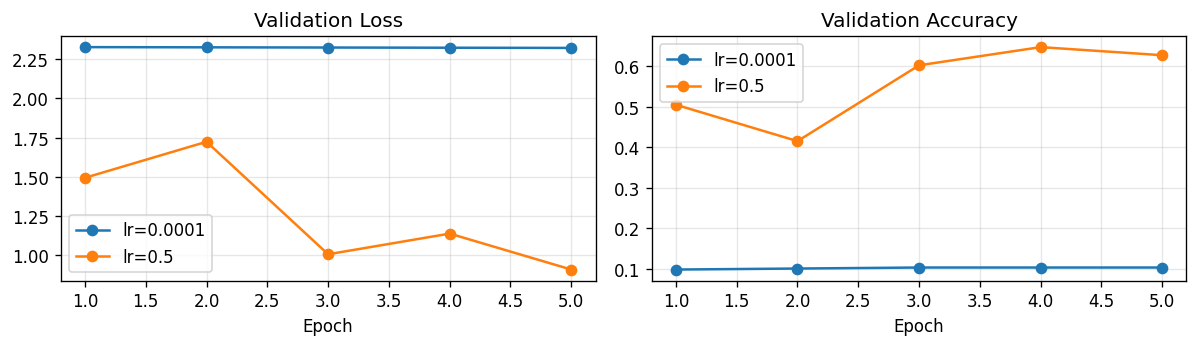


너무 느린 경우: lr=0.0001
불안정한 경우: lr=0.5


In [8]:
exercise2_histories = {}
for lr in [0.0001, 0.5]:
    print(f"\n[SGD lr={lr}]")
    model = BasicMLP(hidden_dim=128, dropout_p=0.0).to(device)
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    exercise2_histories[f"lr={lr}"] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(exercise2_histories)
plot_compare(
    exercise2_histories,
    "val_loss",
    "val_acc",
    "Validation Loss",
    "Validation Accuracy",
)

print("\n너무 느린 경우: lr=0.0001")
print("불안정한 경우: lr=0.5")


### Exercise 3
hidden dimension을 `64`, `128`, `256`으로 비교



[hidden_dim=64]
epoch 1: train_acc=0.5094, val_acc=0.6450
epoch 2: train_acc=0.6887, val_acc=0.7125
epoch 3: train_acc=0.7350, val_acc=0.7200
epoch 4: train_acc=0.7688, val_acc=0.7575
epoch 5: train_acc=0.7794, val_acc=0.7975

[hidden_dim=128]
epoch 1: train_acc=0.5537, val_acc=0.6325
epoch 2: train_acc=0.6925, val_acc=0.7150
epoch 3: train_acc=0.7481, val_acc=0.7525
epoch 4: train_acc=0.7837, val_acc=0.7925
epoch 5: train_acc=0.8013, val_acc=0.7925

[hidden_dim=256]
epoch 1: train_acc=0.5394, val_acc=0.6600
epoch 2: train_acc=0.7200, val_acc=0.6875
epoch 3: train_acc=0.7594, val_acc=0.7800
epoch 4: train_acc=0.8119, val_acc=0.8050
epoch 5: train_acc=0.8237, val_acc=0.8000
   hidden=64 | val_acc=0.7975
  hidden=128 | val_acc=0.7925
  hidden=256 | val_acc=0.8000


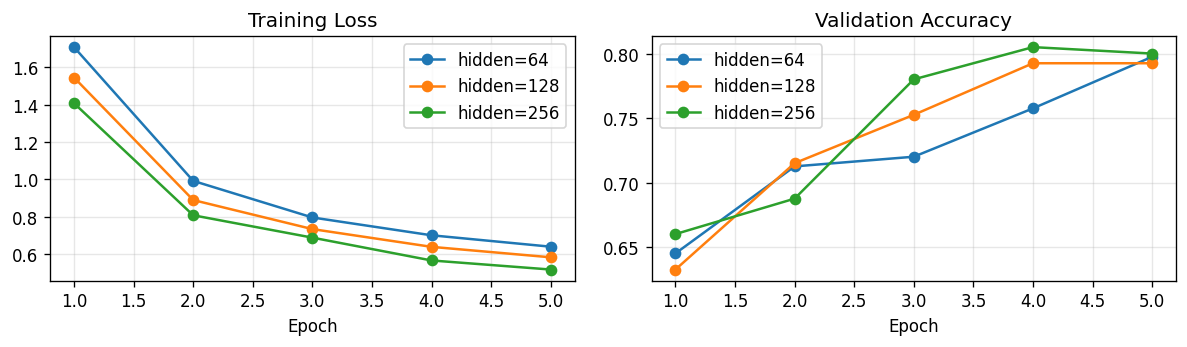

In [9]:
exercise3_histories = {}
for hidden_dim in [64, 128, 256]:
    print(f"\n[hidden_dim={hidden_dim}]")
    model = BasicMLP(hidden_dim=hidden_dim, dropout_p=0.0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    exercise3_histories[f"hidden={hidden_dim}"] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(exercise3_histories)
plot_compare(
    exercise3_histories,
    "train_loss",
    "val_acc",
    "Training Loss",
    "Validation Accuracy",
)


### Exercise 4
weight decay를 `0`, `1e-5`, `1e-3`으로 비교



[weight_decay=0.0]
epoch 1: train_acc=0.5088, val_acc=0.6725
epoch 2: train_acc=0.7019, val_acc=0.7100
epoch 3: train_acc=0.7494, val_acc=0.7500
epoch 4: train_acc=0.7850, val_acc=0.7850
epoch 5: train_acc=0.7994, val_acc=0.8075

[weight_decay=1e-05]
epoch 1: train_acc=0.5519, val_acc=0.6350
epoch 2: train_acc=0.6875, val_acc=0.7050
epoch 3: train_acc=0.7369, val_acc=0.7575
epoch 4: train_acc=0.7750, val_acc=0.7725
epoch 5: train_acc=0.8013, val_acc=0.7875

[weight_decay=0.001]
epoch 1: train_acc=0.5262, val_acc=0.6525
epoch 2: train_acc=0.6937, val_acc=0.7300
epoch 3: train_acc=0.7488, val_acc=0.7675
epoch 4: train_acc=0.7887, val_acc=0.7625
epoch 5: train_acc=0.8044, val_acc=0.7800
      wd=0.0 | val_acc=0.8075
    wd=1e-05 | val_acc=0.7875
    wd=0.001 | val_acc=0.7800


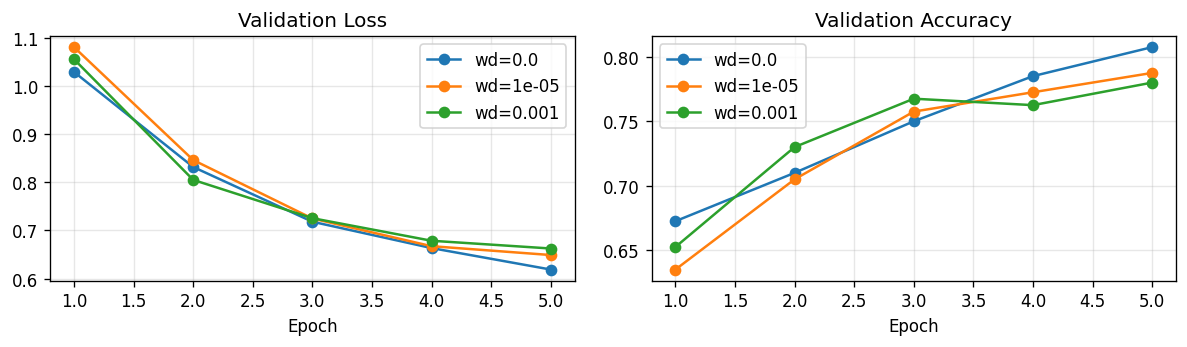

In [10]:
exercise4_histories = {}
for weight_decay in [0.0, 1e-5, 1e-3]:
    print(f"\n[weight_decay={weight_decay}]")
    model = BasicMLP(hidden_dim=128, dropout_p=0.0).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    exercise4_histories[f"wd={weight_decay}"] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(exercise4_histories)
plot_compare(
    exercise4_histories,
    "val_loss",
    "val_acc",
    "Validation Loss",
    "Validation Accuracy",
)


### Exercise 5
dropout 확률을 `0`, `0.1`, `0.5`로 비교



[dropout=0.0]
epoch 1: train_acc=0.5262, val_acc=0.6475
epoch 2: train_acc=0.6950, val_acc=0.7225
epoch 3: train_acc=0.7569, val_acc=0.7275
epoch 4: train_acc=0.7750, val_acc=0.7700
epoch 5: train_acc=0.8050, val_acc=0.8075

[dropout=0.1]
epoch 1: train_acc=0.5344, val_acc=0.6250
epoch 2: train_acc=0.6806, val_acc=0.7375
epoch 3: train_acc=0.7344, val_acc=0.7650
epoch 4: train_acc=0.7719, val_acc=0.7775
epoch 5: train_acc=0.7987, val_acc=0.8125

[dropout=0.5]
epoch 1: train_acc=0.4037, val_acc=0.6375
epoch 2: train_acc=0.5981, val_acc=0.6850
epoch 3: train_acc=0.6756, val_acc=0.7225
epoch 4: train_acc=0.6931, val_acc=0.7375
epoch 5: train_acc=0.7325, val_acc=0.7550
 dropout=0.0 | val_acc=0.8075
 dropout=0.1 | val_acc=0.8125
 dropout=0.5 | val_acc=0.7550


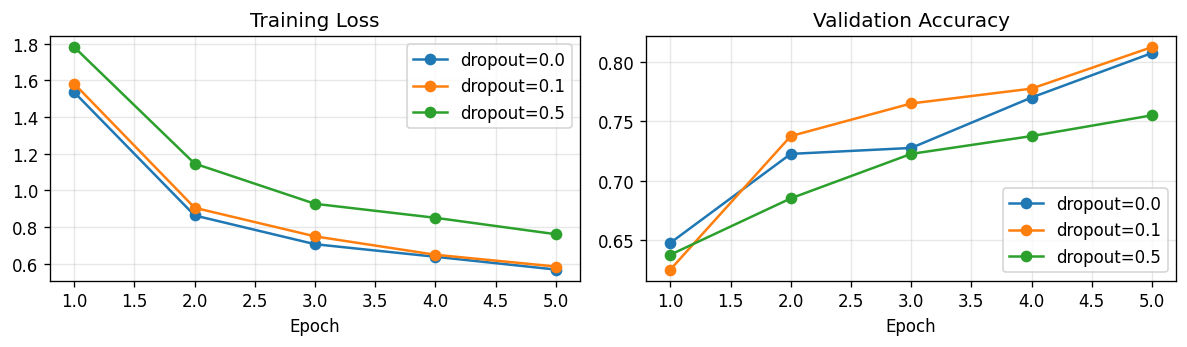

In [11]:
exercise5_histories = {}
for dropout_p in [0.0, 0.1, 0.5]:
    print(f"\n[dropout={dropout_p}]")
    model = BasicMLP(hidden_dim=128, dropout_p=dropout_p).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    exercise5_histories[f"dropout={dropout_p}"] = train_model(
        model, train_loader, val_loader, optimizer, criterion, epochs=5
    )

print_final_acc(exercise5_histories)
plot_compare(
    exercise5_histories,
    "train_loss",
    "val_acc",
    "Training Loss",
    "Validation Accuracy",
)
